<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/ML_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ML FINAL EXAM

### Email: alfattaulislamss@gmail.com

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

## Answer:

I chose the `Titanic Dataset` because it's documented well for binary classification problems and it helps to operate on several problems like handling the missing values, scaling and encoding the numerical and categorical features, and compare multiple models for predictions.

From the observation of this dataset, I saw that it has a mixture of data such as categorical and numerical data. This dataset contains features which have missing values or NaN values that needs to be handled during preprocessing. Also this dataset indicates the `Survived` feature as target feature which is binary.

# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

(891, 12)

891

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Numeric / Quantitative Features: ['PassengerId', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Features: ['Survived', 'Pclass', 'Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']



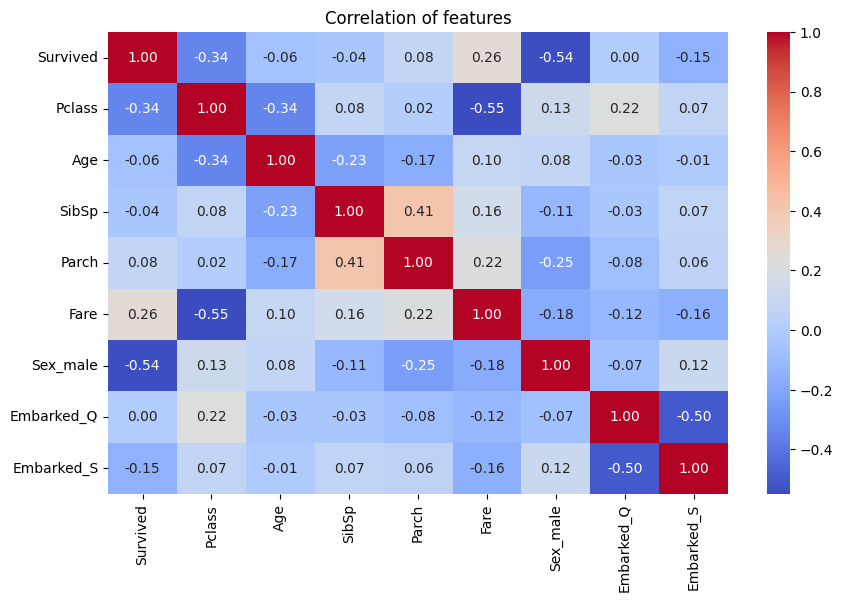


Most Correlated Features: ('Pclass', 'Fare')



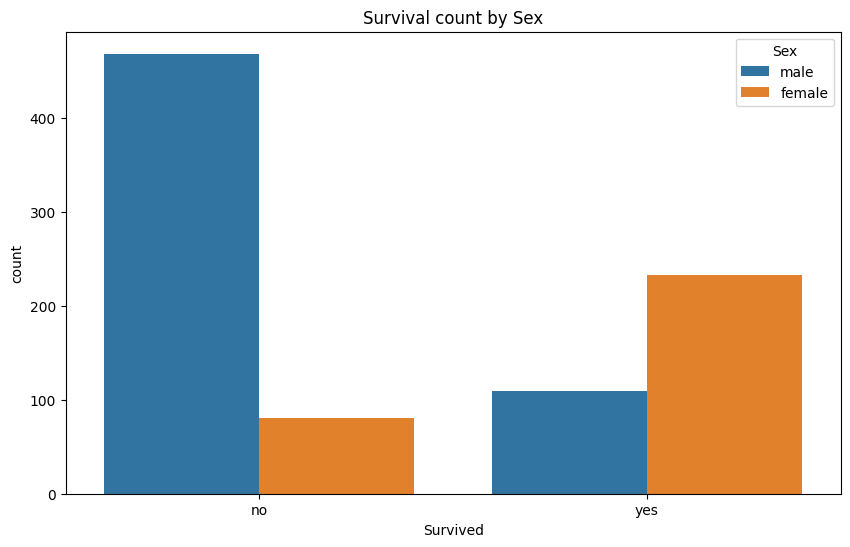

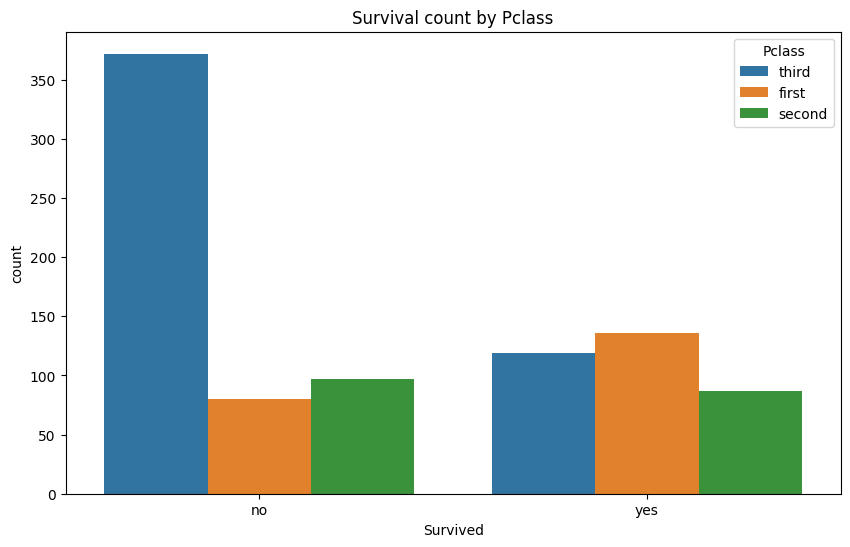

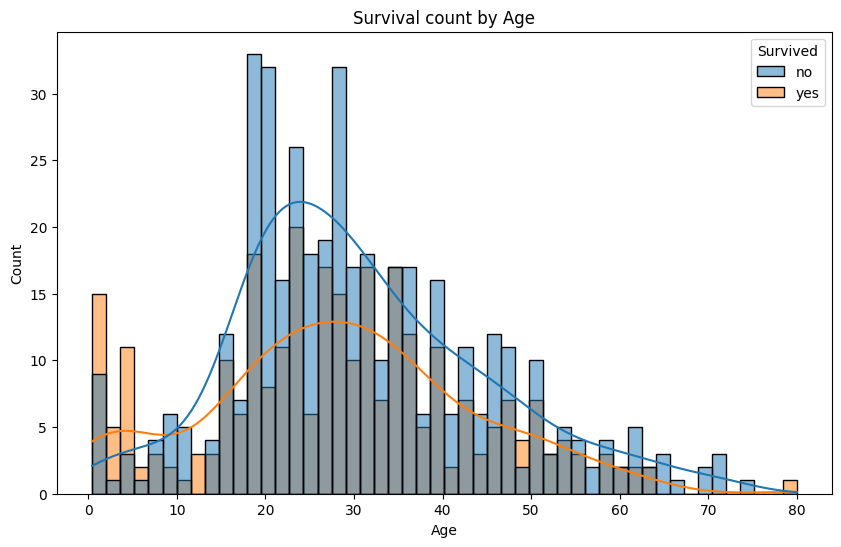

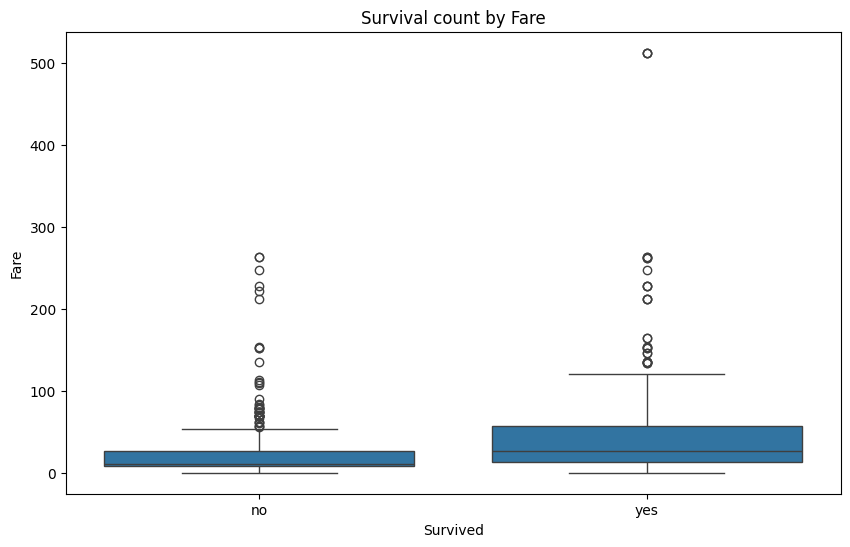

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Load dataset
df_titanic = pd.read_csv('titanic_data_updated.csv')

# How many features?
print(df_titanic.shape)

print()

# How many data points?
print(df_titanic.shape[0])

print()

# Is there any null values?
print(df_titanic.isnull().sum())

print()

# What kind of features are in your dataset? (Quantitative / Categorical)
num_val = df_titanic.select_dtypes(include = ['int64', 'float64']).columns
cat_val = df_titanic.select_dtypes(include = 'object').columns
print('Numeric / Quantitative Features:', list(num_val))
print('Categorical Features:', list(cat_val))

print()

df_copy = df_titanic.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis = 1)

num_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler())
    ]
)

cat_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, drop = 'first', handle_unknown = 'ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers = [
        ('ordinal', OrdinalEncoder(categories=[['no', 'yes'], ['first', 'second', 'third']]), ['Survived', 'Pclass']),
        ('num', num_pipeline, ['Age', 'SibSp', 'Parch', 'Fare']),
        ('cat', cat_pipeline, ['Sex', 'Embarked'])
    ]
)

encoded = preprocessor.fit_transform(df_copy)
labels = [n.split('__')[-1] for n in preprocessor.get_feature_names_out()]

# Correlation of all the features, What do you understand after the correlation test?
corr_matrix = np.corrcoef(encoded.T)

plt.figure(figsize = (10, 6))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', xticklabels = labels, yticklabels = labels)
plt.title('Correlation of features')
plt.show()

print()

corr_df = pd.DataFrame(corr_matrix, index=labels, columns=labels)
np.fill_diagonal(corr_df.values, 0)
correlated = corr_df.abs().stack().sort_values(ascending=False).index[0]
print('Most Correlated Features:', correlated)

print()

# Perform exploratory data analysis to extract some important relationships from your data.
plt.figure(figsize = (10, 6))
sns.countplot(data = df_titanic, x = 'Survived', hue = 'Sex').set_title('Survival count by Sex')
plt.show()

print()

plt.figure(figsize = (10, 6))
sns.countplot(data = df_titanic, x = 'Survived', hue = 'Pclass').set_title('Survival count by Pclass')
plt.show()

print()

plt.figure(figsize = (10, 6))
sns.histplot(data = df_titanic, x = 'Age', hue = 'Survived', kde = True, bins = 50).set_title('Survival count by Age')
plt.show()

print()

plt.figure(figsize = (10, 6))
sns.boxplot(data = df_titanic, x = 'Survived', y = 'Fare').set_title('Survival count by Fare')
plt.show()

## Answer:

### `How many features?`
- Ans: It has total 12 features although the passengerId is an identifier and the Survived column is a target column so in this scenario, the actual input features are 10 excluding these two.

### `Classification or regression problem? Why do you think so?`
- Ans: This dataset is a classification problem because the target feature "Survived" is a binary column which is a classification problem.

### `How many data points?`
- Ans: It has 891 datapoints

### `Is there any null values?`
- Ans: Yes. There are 177 null values for Age, 687 for Cabin and 2 null values for Embarked.

### `What kind of features are in your dataset? (Quantitative / Categorical)`
- Ans: There are both categorical and quantitative data in the dataset.
Quantitative / Numerical : Age, SibSp, Parch, Fare and passengerId although it is an identifier.
Catogorical : Survived, Pclass, Name, Sex, Ticket, Cabin, Embarked although Survived is the target column.

### `Do you need to encode the categorical variables, why or why not?`
- Ans: Yes I need to encode the categorical variables. The categorical variables are objects or string in this dataset which the ML algorigthm can't understand directly. The algorithm understand the mathematical inputs. If I try to train a model with the raw object or string this will throw an error or unreliable result. And that's why I need to properly encode the catgorical varibales in the preprocessing steps.

### `Correlation of all the features, What do you understand after the correlation test?`
- The most correlated features are PClass and Fare which makes sense since higher class tickets cost more. Also, the survived feature is also correlated with Sex_male, pclass and Fare which indicates the survival rate by different ratio. Overall, the correlation test illustrates that the most correlated features are sex, pclass, fare and other features are seemingly moderately correlated.

### `Perform exploratory data analysis to extract some important relationships from your data.`

- From the EDA, I can observe that:
  - The female survived more than male
  - The lowest survival rate is for third pclass
  - The young passengers especially children survived more than older passengers
  - The survival rate is higher for the high fares.

#2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


## Answer:


   

In [24]:
df_copy = df_titanic.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis = 1)

num_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler())
    ]
)

cat_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, drop = 'first', handle_unknown = 'ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers = [
        ('ordinal', OrdinalEncoder(categories=[['no', 'yes'], ['first', 'second', 'third']]), ['Survived', 'Pclass']),
        ('num', num_pipeline, ['Age', 'SibSp', 'Parch', 'Fare']),
        ('cat', cat_pipeline, ['Sex', 'Embarked'])
    ]
)

preprocessor

ColumnTransformer(transformers=[('ordinal',
                                 OrdinalEncoder(categories=[['no', 'yes'],
                                                            ['first', 'second',
                                                             'third']]),
                                 ['Survived', 'Pclass']),
                                ('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'SibSp', 'Parch', 'Fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Sex', 'Embarked'])])

### Discuss the pre processing steps you applied and why?
- Hence are discussed the preprocessing steps applied and why:
  - First, I dropped PassengerId, Name, Ticket, and Cabin from the dataset. PassengerId is just a row identifier with no predictive value. Name is irrelevant to survival. Ticket is a mixture of string and numeric values with no clean structure to extract. Cabin has too many null values to reliably impute or use.

  - Then I created a numerical pipeline for the numerical features such as Age, SibSp, Parch, Fare. I used SimpleImputer with the median strategy, since median is more robust to outliers than mean, a few very high fares or ages wouldn't skew the median the way they would the mean. I then used StandardScaler to scale the values, centering them around 0 with unit variance. This matters because features like Age and Fare are on very different numeric ranges, and models sensitive to feature scale which can be biased toward whichever feature has the largest raw magnitude if left unscaled.

  - I also created a categorical pipeline for the categorical features such as Sex, Embarked. I used the most-frequent strategy in the imputer since these are object values, and mean/median don't apply. I used OneHotEncoder to encode them, with handle_unknown = 'ignore' to avoid errors if an unseen category shows up at prediction time. Sex and Embarked don't have any natural order, so one-hot encoding is appropriate for them unlike Pclass, which does have a meaningful order, so I encoded that one with OrdinalEncoder instead.

  - In the ColumnTransformer step, I combined all three: the ordinal encoder for Pclass and for this section, Survived, the numeric pipeline, and the categorical pipeline, into a single preprocessor. The survived feature is the target variable here.

  - Wrapping everything in a single ColumnTransformer / Pipeline means missing value handling, scaling, and encoding are all applied consistently in one step, rather than repeating the logic manually every time the data needs to be transformed and it also avoids data leakage later, since the same fitted transformer can be applied to train and test sets consistently.

#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:



#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

# 5. Model Training (5 marks)

Train those 2 models



## Answer:

#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer: